# Kuzmin LOOCV HAVEN Fine Tuning Analysis

In [2]:
# from src.evaluation.binary_class_evaluation import 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score, precision_recall_curve
import sys, os, subprocess


In [3]:
kuzmin = pd.read_csv("../../../../input/data/kuzmin/kuzmin_no_gaps.csv")
witheld = kuzmin[kuzmin['virus_species'] != "Severe_acute_respiratory_syndrome_related_coronavirus"]

In [4]:
kuzmin = kuzmin.drop('Unnamed: 0', axis=1)
kuzmin.to_csv("../../../../input/data/kuzmin/kuzmin_no_gaps.csv")

In [6]:
human_virus_species_set = {
    "Human_coronavirus_NL63",
    "Betacoronavirus_1",
    "Human_coronavirus_HKU1",
    "Severe_acute_respiratory_syndrome_related_coronavirus",
    "SARS_CoV_2",
    "Human_coronavirus_229E",
    "Middle_East_respiratory_syndrome_coronavirus",
}

virus_list = witheld['virus_species'].unique()

def is_human_virus(virus_species):
    if virus_species in human_virus_species_set:
        return 1
    else: 
        return 0
    
def get_virus_species(itr):
    return virus_list[itr]

def merge_cols(row):
    positive_label = row[2]
    one = row[6]
    if not pd.isna(positive_label):
        return positive_label
    else:
        return one
    
    

In [6]:
results = pd.read_csv("kuzmin_hybrid_attention_LOOCV_2l_d1024_lr3e-4_output.csv")
results['virus_species'] = results['itr'].apply(get_virus_species)
results['target'] = results['virus_species'].apply(is_human_virus)
results['target_pred'] = results.apply(merge_cols, axis=1)

In [7]:
fpr, tpr, _ = roc_curve(results['target'], results['target_pred'])
auc = roc_auc_score(results['target'], results['target_pred'])

In [8]:
# Get average pred by species 
results_by_species = results.groupby('virus_species').agg("mean").reset_index()
# display(results_by_species)
fpr_species, tpr_species, _ = roc_curve(results_by_species['target'], results_by_species['target_pred'])
auc_species = roc_auc_score(results_by_species['target'], results_by_species['target_pred'])

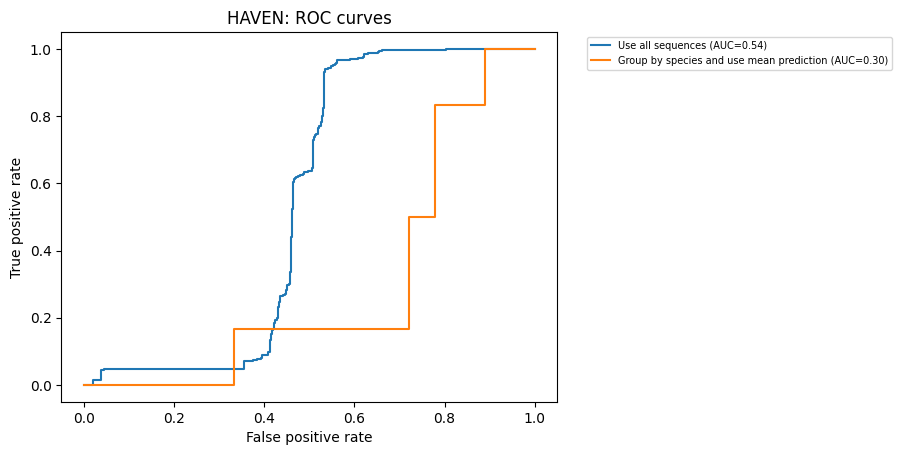

In [9]:
plt.step(fpr, tpr, where="post", label="Use all sequences (AUC=%.2f)" % (auc,))
plt.step(fpr_species,tpr_species,where="post",label="Group by species and use mean prediction (AUC=%.2f)" % (auc_species,),)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("HAVEN: ROC curves")
plt.legend(loc="upper left", fontsize=7, bbox_to_anchor=(1.05, 1))
plt.savefig('model_eval_ROC.jpg', bbox_inches='tight')

plt.show()

# Replicates of HAVEN Fine Tuning

In [ ]:
staging_folder = "aranastasi@ap2001.chtc.wisc.edu:/staging/aranastasi/HAVEN/outputs/LOOCV_reps"

for rep in range(0, 4):
    # Download and untar fine tuning models 

    subprocess.run(["mkdir", "-p", f"rep{rep}"])
    
    subprocess.run(
        [
            "scp",
            f"{staging_folder}/kuzmin_LOOCV_fine_tuning_rep{rep}.tar.gz" f"rep{rep}",
        ]
    ) 

    # print(f"Command: gtar -xzf {local_bagged_CV_folder}/{subfolder_name}.tar.gz -C {local_bagged_CV_folder}/")

    subprocess.run(
        [
            "gtar",
            "-xzf",
            f"rep{rep}/kuzmin_LOOCV_fine_tuning_rep{rep}.tar.gz",
            "-C",
            f"outputs/",
        ]
    )

usage: scp [-346ABCOpqRrsTv] [-c cipher] [-D sftp_server_path] [-F ssh_config]
           [-i identity_file] [-J destination] [-l limit] [-o ssh_option]
           [-P port] [-S program] [-X sftp_option] source ... target
tar (child): kuzmin_LOOCV_fine_tuning_rep0.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
gtar: Child returned status 2
gtar: Error is not recoverable: exiting now
usage: scp [-346ABCOpqRrsTv] [-c cipher] [-D sftp_server_path] [-F ssh_config]
           [-i identity_file] [-J destination] [-l limit] [-o ssh_option]
           [-P port] [-S program] [-X sftp_option] source ... target
tar (child): kuzmin_LOOCV_fine_tuning_rep1.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
gtar: Child returned status 2
gtar: Error is not recoverable: exiting now
usage: scp [-346ABCOpqRrsTv] [-c cipher] [-D sftp_server_path] [-F ssh_config]
           [-i identity_file] [-J destination] 

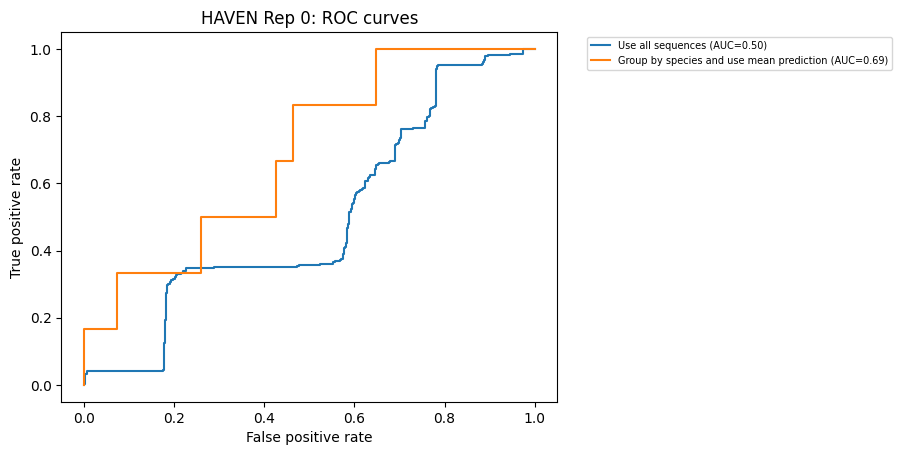

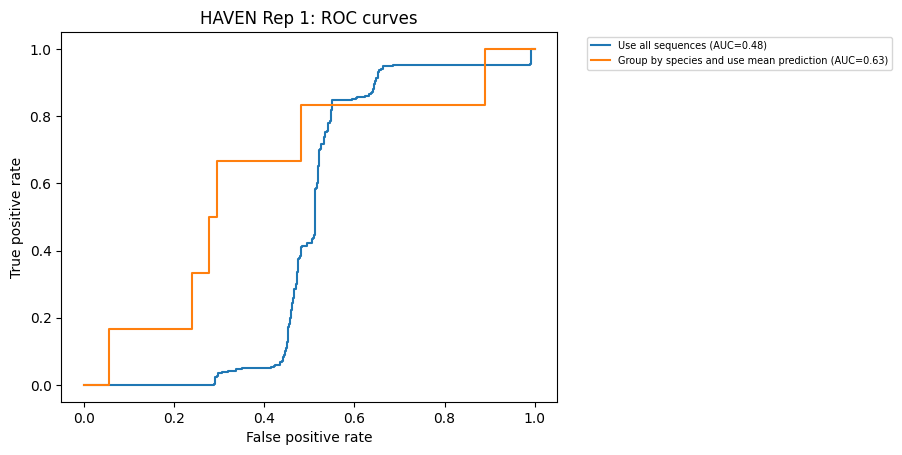

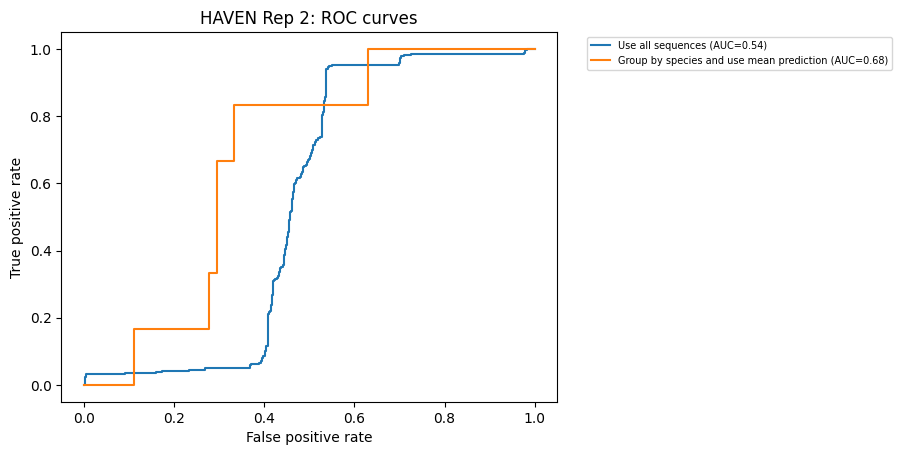

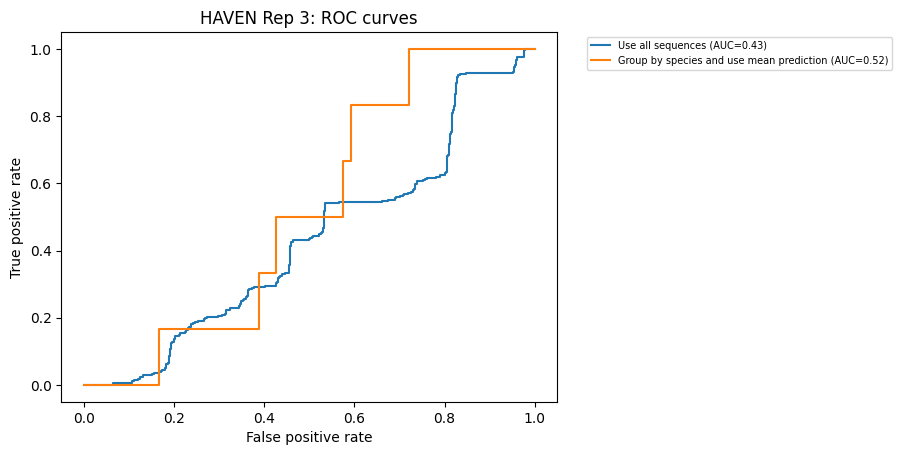

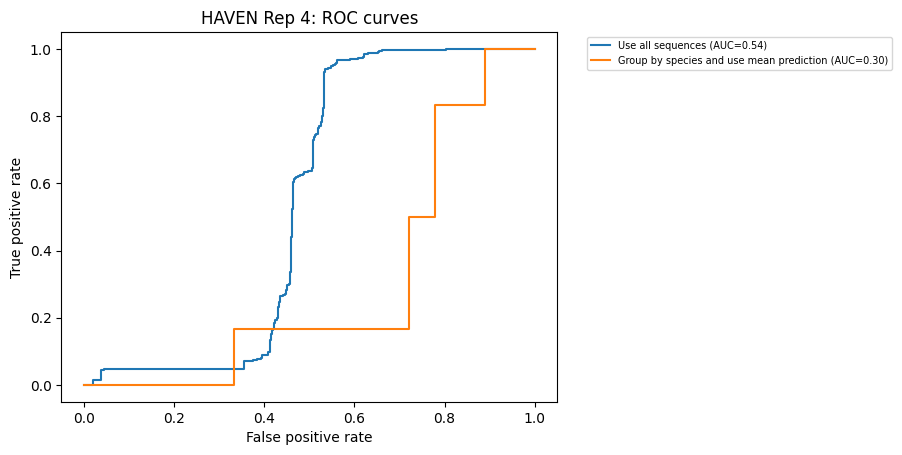

In [22]:
for rep in range(0, 5):
    results = pd.read_csv(f"rep{rep}/kuzmin_hybrid_attention_LOOCV_2l_d1024_lr3e-4_output.csv")
    results['virus_species'] = results['itr'].apply(get_virus_species)
    results['target'] = results['virus_species'].apply(is_human_virus)
    results['target_pred'] = results.apply(merge_cols, axis=1)

    # display(results)
    
    fpr, tpr, _ = roc_curve(results['target'], results['target_pred'])
    auc = roc_auc_score(results['target'], results['target_pred'])

    # Get average pred by species 
    results_by_species = results.groupby('virus_species').agg("mean").reset_index()
    # display(results_by_species)
    fpr_species, tpr_species, _ = roc_curve(results_by_species['target'], results_by_species['target_pred'])
    auc_species = roc_auc_score(results_by_species['target'], results_by_species['target_pred'])

    plt.step(fpr, tpr, where="post", label="Use all sequences (AUC=%.2f)" % (auc,))
    plt.step(fpr_species,tpr_species,where="post",label="Group by species and use mean prediction (AUC=%.2f)" % (auc_species,),)

    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"HAVEN Rep {rep}: ROC curves")
    plt.legend(loc="upper left", fontsize=7, bbox_to_anchor=(1.05, 1))
    plt.savefig('model_eval_ROC.jpg', bbox_inches='tight')

    plt.show()

    if rep != 4:
        plt.cla()

# Results of Test Run

This run had an 80/10/10 split of training, validation, and test without leaving anything out. 

In [11]:
kuzmin_test = pd.read_csv("kuzmin_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
kuzmin_test.sample(10)

,Unnamed: 0,negative_label,positive_label,y_true,itr
552,56,0.061503,0.938497,positive_label,4
282,34,0.046093,0.953908,positive_label,2
129,5,0.021252,0.978748,positive_label,1
452,80,0.181822,0.818178,positive_label,3
223,99,0.030309,0.969691,positive_label,1
436,64,0.909964,0.090035,negative_label,3
479,107,0.955828,0.044172,negative_label,3
58,58,0.031237,0.968763,positive_label,0
286,38,0.935664,0.064336,negative_label,2
118,118,0.965147,0.034853,negative_label,0


In [12]:
def transform_target(y_true):
    if y_true == "positive_label":
        return 1
    else: return 0

kuzmin_test['target'] = kuzmin_test['y_true'].apply(transform_target)
kuzmin_test

,Unnamed: 0,negative_label,positive_label,y_true,itr,target
0,0,0.939457,0.060543,negative_label,0,0
1,1,0.944057,0.055943,negative_label,0,0
2,2,0.022671,0.977329,positive_label,0,1
3,3,0.960016,0.039984,negative_label,0,0
4,4,0.976094,0.023906,negative_label,0,0
...,...,...,...,...,...,...
615,119,0.050357,0.949643,positive_label,4,1
616,120,0.948105,0.051895,negative_label,4,0
617,121,0.972137,0.027863,negative_label,4,0
618,122,0.063077,0.936923,positive_label,4,1


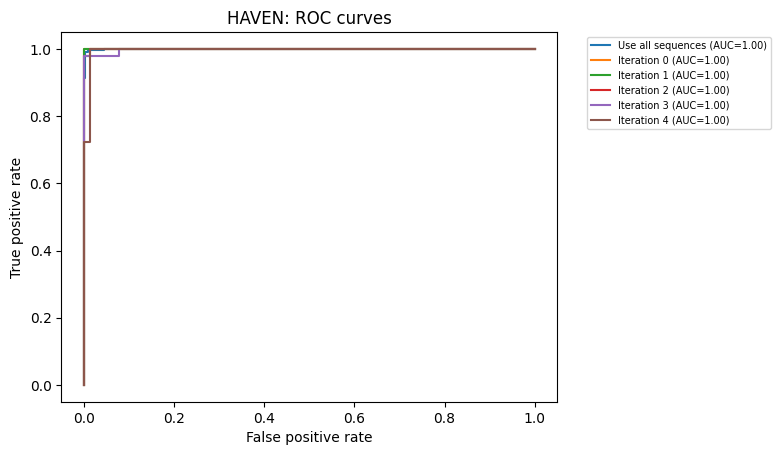

In [14]:

fpr, tpr, _ = roc_curve(kuzmin_test['target'].values, kuzmin_test['positive_label'].values)
auc = roc_auc_score(kuzmin_test['target'].values, kuzmin_test['positive_label'].values)

plt.step(fpr, tpr, where="post", label="Use all sequences (AUC=%.2f)" % (auc,))

for i in range(0,5):
    curr_itr = kuzmin_test[kuzmin_test['itr'] == i]
    fpr, tpr, _ = roc_curve(curr_itr['target'].values, curr_itr['positive_label'].values)
    auc = roc_auc_score(curr_itr['target'].values, curr_itr['positive_label'].values)

    plt.step(fpr, tpr, where="post", label=f"Iteration {i} (AUC={auc:.2f})")


plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("HAVEN: ROC curves")
plt.legend(loc="upper left", fontsize=7, bbox_to_anchor=(1.05, 1))
plt.savefig('model_eval_ROC_test.jpg', bbox_inches='tight')

plt.show()

# Replicates without Validation Set

In these replicates, we chose to remove the validation set and have all of the data used as training considering that our dataset is quite small. 

In [3]:
staging_folder = "aranastasi@ap2001.chtc.wisc.edu:/staging/aranastasi/HAVEN/outputs/LOOCV_without_validation_reps"

for rep in [1,4]:
    # Download and untar fine tuning models 
    
    subprocess.run(["mkdir", "-p", f"without_validation/rep{rep}"])
    
    subprocess.run(
        [
            "scp",
            f"{staging_folder}/kuzmin_LOOCV_fine_tuning_rep{rep}.tar.gz", f"without_validation/rep{rep}",
        ]
    ) 

    # print(f"Command: gtar -xzf {local_bagged_CV_folder}/{subfolder_name}.tar.gz -C {local_bagged_CV_folder}/")

    subprocess.run(
        [
            "gtar",
            "-xzf",
            f"without_validation/rep{rep}/kuzmin_LOOCV_fine_tuning_rep{rep}.tar.gz", "-C", f"without_validation/rep{rep}",
        ]
    )

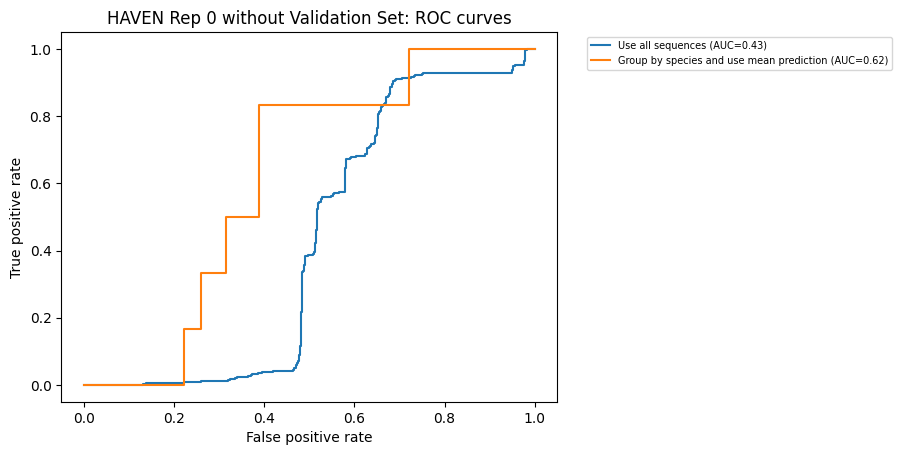

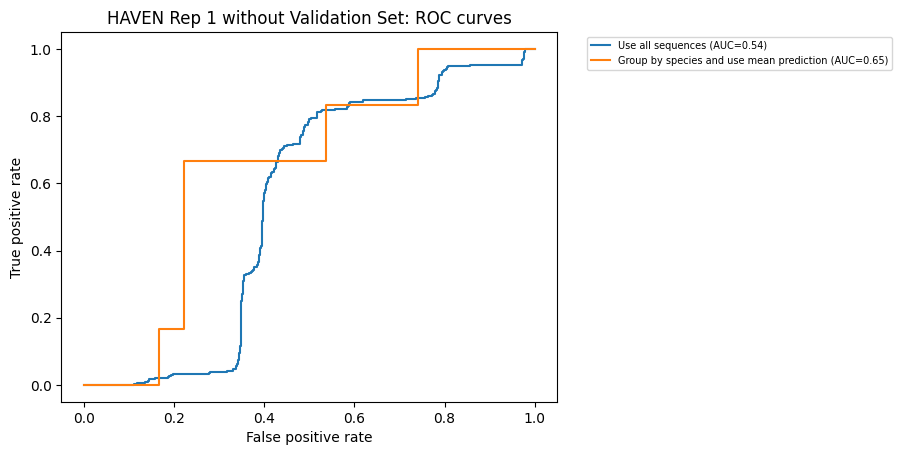

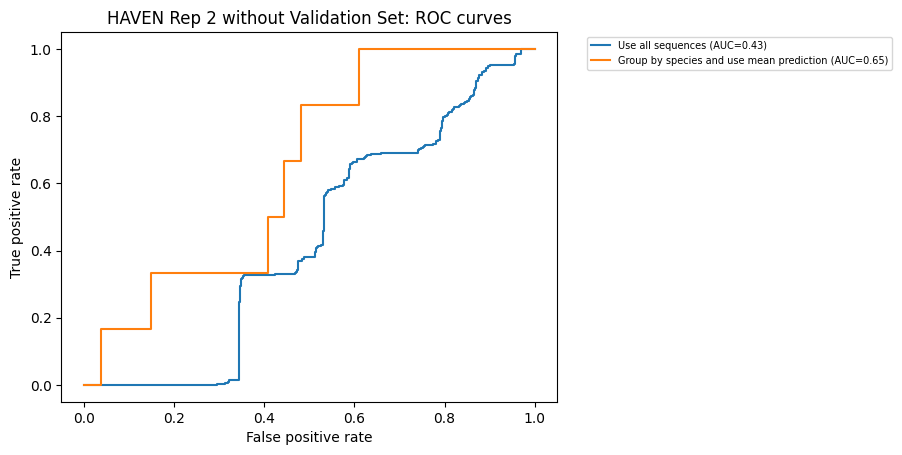

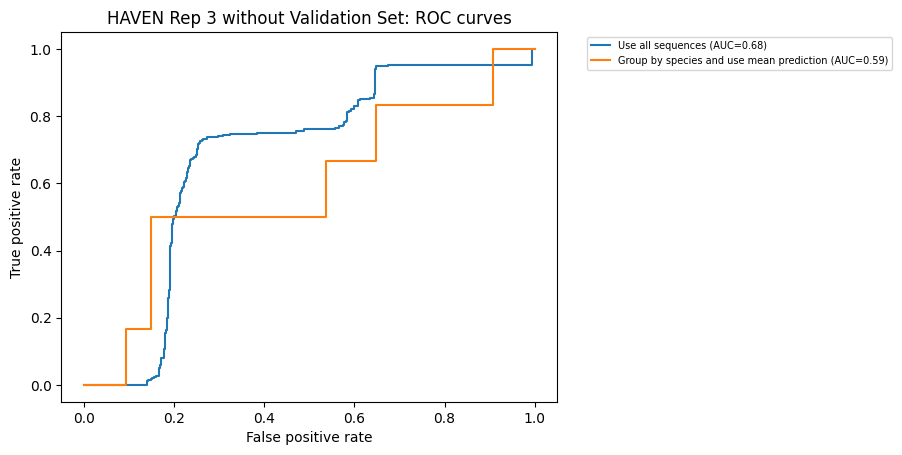

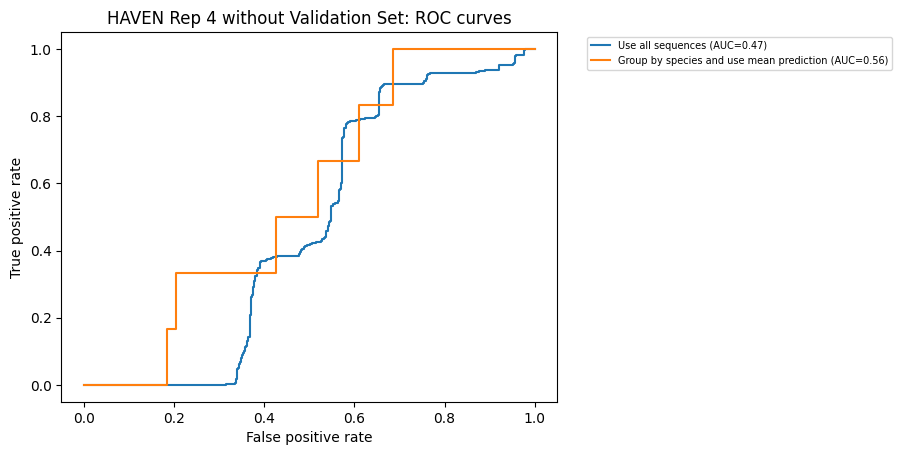

In [7]:
for rep in range(0,5):
    results = pd.read_csv(f"without_validation/rep{rep}/kuzmin_hybrid_attention_LOOCV_2l_d1024_lr3e-4_output.csv")
    results['virus_species'] = results['itr'].apply(get_virus_species)
    results['target'] = results['virus_species'].apply(is_human_virus)
    results['target_pred'] = results.apply(merge_cols, axis=1)

    # display(results)
    
    fpr, tpr, _ = roc_curve(results['target'], results['target_pred'])
    auc = roc_auc_score(results['target'], results['target_pred'])

    # Get average pred by species 
    results_by_species = results.groupby('virus_species').agg("mean").reset_index()
    # display(results_by_species)
    fpr_species, tpr_species, _ = roc_curve(results_by_species['target'], results_by_species['target_pred'])
    auc_species = roc_auc_score(results_by_species['target'], results_by_species['target_pred'])

    plt.step(fpr, tpr, where="post", label="Use all sequences (AUC=%.2f)" % (auc,))
    plt.step(fpr_species,tpr_species,where="post",label="Group by species and use mean prediction (AUC=%.2f)" % (auc_species,),)

    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"HAVEN Rep {rep} without Validation Set: ROC curves")
    plt.legend(loc="upper left", fontsize=7, bbox_to_anchor=(1.05, 1))
    plt.savefig('model_eval_ROC.jpg', bbox_inches='tight')

    plt.show()

    if rep != 4:
        plt.cla()

## Training Loss by Epoch

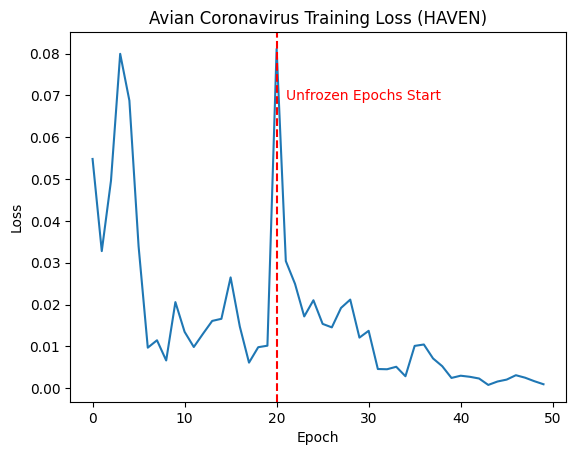

In [8]:
def set_training_epoch(step):
    return (step // 59) + 1

training_loss_df = pd.read_csv("without_validation/without_validation_training_loss.csv")
training_loss_df['epoch'] = training_loss_df.index.map(set_training_epoch)
training_loss_df = training_loss_df.rename(columns = {'iter_0_Avian_coronavirus - training-loss' : 'training_loss'})
training_loss_grouped = training_loss_df[['epoch', 'training_loss']]
training_loss_grouped = training_loss_grouped.groupby("epoch").agg('mean').reset_index()

plt.plot(training_loss_grouped['training_loss'])
plt.title(f"Avian Coronavirus Training Loss (HAVEN)")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.axvline(x=20, color='r', linestyle='--', label='Unfrozen Epochs Start')
plt.text(21, .07, 'Unfrozen Epochs Start', verticalalignment='center', color='r')
plt.show()